In [50]:
pip install requests numpy pandas matplotlib torch prophet scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import requests
import pandas as pd

FORECAST_HOURS = 24

latitude = 52.2297
longitude = 21.0122

url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}&hourly=temperature_2m&past_days=2"
)

response = requests.get(url)
data = response.json()
temperatures = data['hourly']['temperature_2m']
times = data['hourly']['time']

df = pd.DataFrame({'time': times, 'temperature': temperatures})
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

train_df = df.iloc[:-FORECAST_HOURS]
test_df = df.iloc[-FORECAST_HOURS:]

In [ ]:
from prophet import Prophet

df_prophet = train_df.rename(columns={'time': 'ds', 'temperature': 'y'})
model_prophet = Prophet()
model_prophet.fit(df_prophet)

future = test_df[['time']].rename(columns={'time': 'ds'})
forecast = model_prophet.predict(future)
prophet_preds = forecast['yhat_lower'].values

00:35:08 - cmdstanpy - INFO - Chain [1] start processing
00:35:08 - cmdstanpy - INFO - Chain [1] done processing


                    ds       yhat  yhat_lower  yhat_upper
19 2025-06-24 19:00:00  32.037043   29.624071   34.557126
20 2025-06-24 20:00:00  30.966245   28.665097   33.281793
21 2025-06-24 21:00:00  30.092290   27.893612   32.516969
22 2025-06-24 22:00:00  29.517727   27.118299   31.753041
23 2025-06-24 23:00:00  29.110615   26.880143   31.453869


In [ ]:
import torch
import numpy as np

model = torch.jit.load("weather_lstm_model.pt")
model.eval()

SCALER_MEAN = 9.45
SCALER_STD = 8.42
SEQUENCE_LENGTH = 24

seq = train_df['temperature'].values[-SEQUENCE_LENGTH:]
y_pred = []

for i in range(FORECAST_HOURS):
    seq_scaled = (np.array(seq) - SCALER_MEAN) / SCALER_STD
    x_input = torch.tensor(seq_scaled, dtype=torch.float32).reshape(1, SEQUENCE_LENGTH, 1)
    with torch.no_grad():
        pred_scaled = model(x_input).squeeze(0)
    pred = float(pred_scaled[0].numpy() * SCALER_STD + SCALER_MEAN)
    y_pred.append(pred)
    seq = np.append(seq[1:], pred)

my_model_preds = np.array(y_pred)
y_true = test_df['temperature'].values

[23.92309189 23.28725433 22.59283829 21.46361923 20.13121796 19.49334717
 19.71997452 20.16897011 20.65524292 21.54187965 22.42432594 23.12327576
 23.39453506 23.25806808 22.9268074  22.65642166 22.41035461 21.81338882
 21.02539444 20.38217926 19.94522476 19.64115715 19.46862793 19.48619461]


In [54]:
from sklearn.metrics import mean_squared_error

mse_my = mean_squared_error(y_true, my_model_preds)
mse_prophet = mean_squared_error(y_true, prophet_preds)

print(f"MSE Twój model: {mse_my:.2f}")
print(f"MSE Prophet: {mse_prophet:.2f}")

MSE Twój model: 1.98
MSE Prophet: 61.46


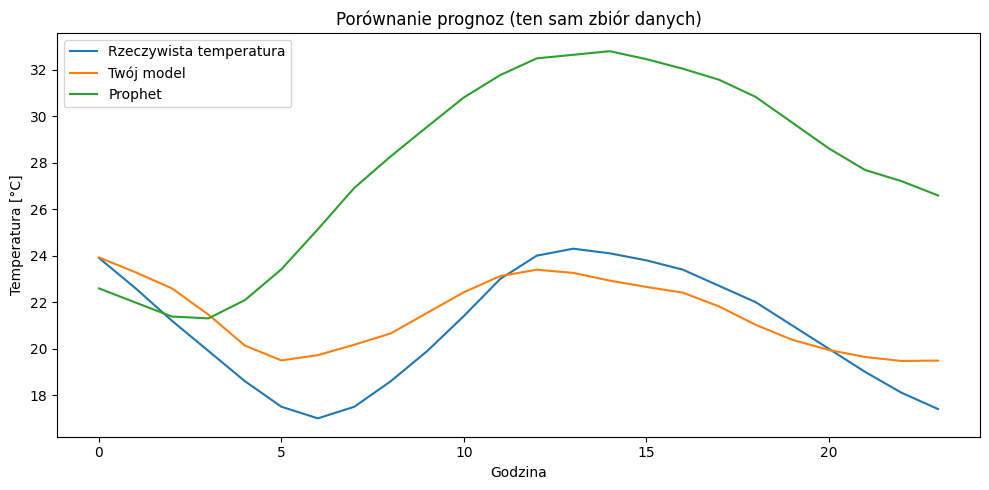

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_true, label='Rzeczywista temperatura')
plt.plot(my_model_preds, label='Twój model')
plt.plot(prophet_preds, label='Prophet')
plt.legend()
plt.title('Porównanie prognoz (ten sam zbiór danych)')
plt.xlabel('Godzina')
plt.ylabel('Temperatura [°C]')
plt.tight_layout()
plt.show()